In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pickle
import warnings
warnings.filterwarnings('ignore')


In [2]:

X_train = pd.read_csv('E:/DATA ANAYLST PROJECTS/Customer-churn/data/X_train.csv')
X_test = pd.read_csv('E:/DATA ANAYLST PROJECTS/Customer-churn/data/X_test.csv')
y_train = pd.read_csv('E:/DATA ANAYLST PROJECTS/Customer-churn/data/y_train.csv').values.ravel()
y_test = pd.read_csv('E:/DATA ANAYLST PROJECTS/Customer-churn/data/y_test.csv').values.ravel()

print("Data loaded successfully!")
print("X_train shape:", X_train.shape)

Data loaded successfully!
X_train shape: (8260, 19)


In [3]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds))
    print(f"ROC-AUC Score: {auc:.4f}")


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.82      0.77      0.80      1037
           1       0.78      0.83      0.81      1029

    accuracy                           0.80      2066
   macro avg       0.80      0.80      0.80      2066
weighted avg       0.80      0.80      0.80      2066

ROC-AUC Score: 0.8861

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1037
           1       0.84      0.83      0.84      1029

    accuracy                           0.84      2066
   macro avg       0.84      0.84      0.84      2066
weighted avg       0.84      0.84      0.84      2066

ROC-AUC Score: 0.9183

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1037
           1       0.81      0.85      0.83      1029

    accuracy                           0.83      2066
   ma

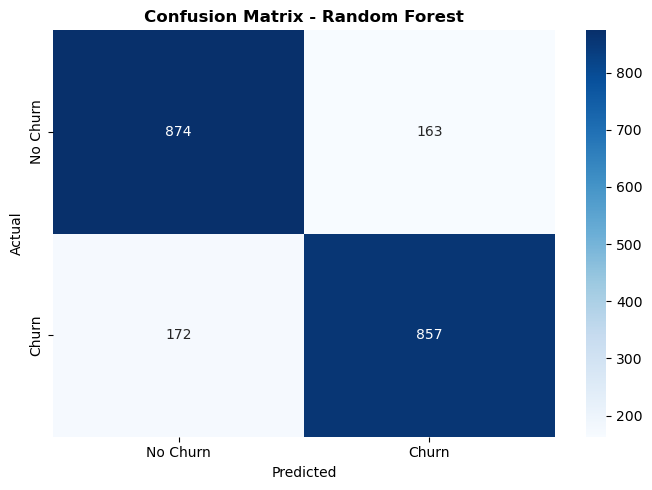

Confusion matrix saved!


In [4]:
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'], 
            yticklabels=['No Churn','Churn'])
plt.title('Confusion Matrix - Random Forest', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('E:/DATA ANAYLST PROJECTS/Customer-churn/data/confusion_matrix.png', dpi=150)
plt.show()

print("Confusion matrix saved!")

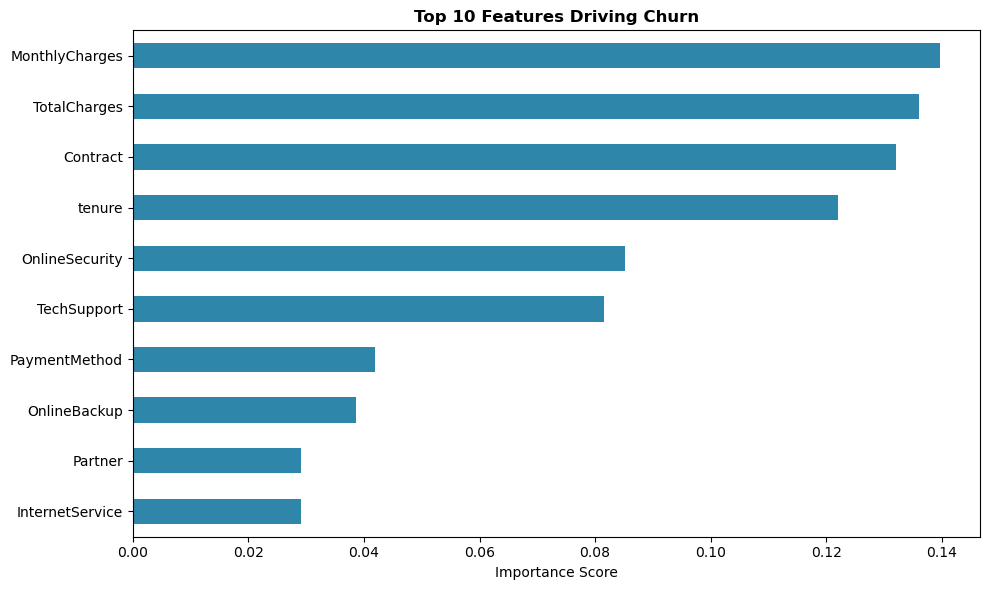

Feature importance saved!


In [5]:
feature_imp = pd.Series(best_model.feature_importances_,
                        index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_imp.head(10).plot(kind='barh', color='#2E86AB')
plt.title('Top 10 Features Driving Churn', fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('E:/DATA ANAYLST PROJECTS/Customer-churn/data/feature_importance.png', dpi=150)
plt.show()

# Save for Power BI
feature_imp.reset_index().rename(
    columns={'index':'Feature', 0:'Importance'}).to_csv(
    'E:/DATA ANAYLST PROJECTS/Customer-churn/data/feature_importance.csv', index=False)

print("Feature importance saved!")

In [6]:
tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

cost_per_missed = 500
total_cost = fn * cost_per_missed

print("=== BUSINESS IMPACT ===")
print(f"Customers correctly identified as churners: {tp}")
print(f"Churners our model MISSED: {fn}")
print(f"Estimated monthly cost of missed churners: Rs. {total_cost:,}")
print(f"If we retain 30% of flagged churners, savings = Rs. {int(tp*0.3*500):,}/month")

=== BUSINESS IMPACT ===
Customers correctly identified as churners: 857
Churners our model MISSED: 172
Estimated monthly cost of missed churners: Rs. 86,000
If we retain 30% of flagged churners, savings = Rs. 128,549/month


In [7]:
with open('E:/DATA ANAYLST PROJECTS/Customer-churn/models/best_churn_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model saved successfully!")

Model saved successfully!
